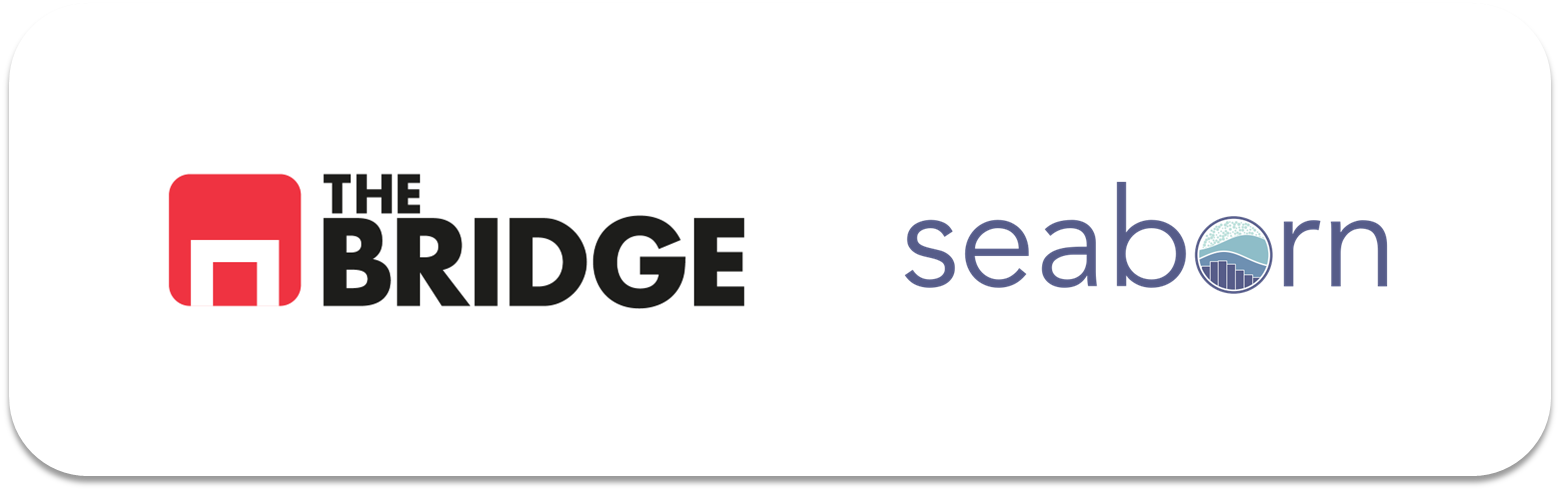

## PRACTICA OBLIGATORIA: **Visualización y Presentación**

* La práctica obligatoria de esta unidad se divide en dos partes, una dedicada a visualización y construcción de funciones, y la otra a hacer una presentación de resultados. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## #1 VISUALIZACION

### #1.1

Carga el dataset de las ciudades de California que está en la ruta "./data/california_cities.csv". Muestra su contenido, deshazte de las filas con nulos.

In [4]:
df = pd.read_csv('./data/california_cities.csv')
df.info()
df.dropna()

<class 'pandas.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    str    
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         434 non-null    float64
 5   elevation_ft        470 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    480 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    481 non-null    float64
 10  area_total_km2      477 non-null    float64
 11  area_land_km2       478 non-null    float64
 12  area_water_km2      478 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), str(1)
memory usage: 52.8 KB


,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
5,5,AlisoViejo,33.575000,-117.725556,127.0,417.0,47823,7.472,7.472,0.000,19.352,19.352,0.000,0.00
6,6,Alturas,41.487222,-120.542500,1332.0,4370.0,2827,2.449,2.435,0.014,6.342,6.306,0.036,0.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,477,Yountville,38.403056,-122.362222,30.0,98.0,2933,1.531,1.531,0.000,3.966,3.966,0.000,0.00
478,478,Yreka,41.726667,-122.637500,787.0,2582.0,7765,10.053,9.980,0.073,26.036,25.847,0.188,0.72
479,479,YubaCity,39.134722,-121.626111,18.0,59.0,64925,14.656,14.578,0.078,37.959,37.758,0.201,0.53
480,480,Yucaipa,34.030278,-117.048611,798.0,2618.0,51367,27.893,27.888,0.005,72.244,72.231,0.013,0.02


### #1.2

Crea una función similar a la que se pide en el ejercicio 6 de la segunda tanda de ejercicios del workout. Es decir, una función para pintar diagramas de dispersion que tenga seis argumentos, pero ojo al cambio en el quinto:
1. Un dataframe
2. Una columna numérica del dataframe
3. Una columna numérica del dataframe diferente a la anterior.
4. Un columna categórica (Opcional, valor por defecto None)
5. Un valor para el tamaño de los puntos o una cadena, pero que puede ser una cadena de caracteres, en cuyo caso se debe interpretar como una de las columnas del dataframe cuyos valores deben controlar el tamaño
6. Un sexto argumento "escala", que permita manipular la escala del tamaño en el caso de que el quinto argumento sea una cadena. Este argumento multiplicará a los valores de la columna indicada en el parámetro anterior (así si quiero dividir por 10000, este sexto argumento tendrá que valer 1/10000)

La función debe pintar el diagrama de dispersión de la columna numérica 1, en el eje X, frente a la columna numérica 2, en el eje Y, usando un código de colores en función de la columna categórica y con el tamaño de los puntos según el argumento correspondiente. 

Si no se diera una columna categórica como argumento, el color no debe pasarse como parámetro a la función de Seaborn o Matplotlib que uses.

EXTRA OPCIONAL: Añade un argumento que controle si la función pinta una leyenda para colores y tamaños o un colorbar y una leyenda para los tamaños.

In [5]:
def scatter_plot(df, x_col, y_col, cat_col=None, size=50, escala=1):

    # ── RESOLUCIÓN DEL TAMAÑO ─────────────────────────────────────────────────
    # isinstance() comprueba el tipo del argumento en tiempo de ejecución.
    if isinstance(size, str):
        # size es un nombre de columna → extraemos esa columna y la escalamos.
        point_sizes = df[size] * escala
    else:
        # size es un número → tamaño fijo igual para todos los puntos.
        point_sizes = size

    # ── CONSTRUCCIÓN DINÁMICA DE ARGUMENTOS ──────────────────────────────────

    kwargs = {'data': df, 'x': x_col, 'y': y_col}
    if cat_col is not None:
        kwargs['hue'] = cat_col   # codificación de color por categoría

    if isinstance(size, str):
        # Pasamos la Series como 'size' para que seaborn gestione la leyenda de tamaños.
        kwargs['size']  = point_sizes
        kwargs['sizes'] = (point_sizes.min(), point_sizes.max())
    else:
        # Pasamos el array de tamaños escalados como 's' para que matplotlib gestione el tamaño de los puntos.
        kwargs['s'] = point_sizes

    # ── DIBUJO ───────────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 8))

    # Seaborn gestiona automáticamente la leyenda de colores (hue) y de tamaños (size).
    sns.scatterplot(**kwargs)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()




### #1.3

Pinta el diagrama de dispersión de longitud y latitud (longitud en las x, latitud en las y) de las ciudades, usando el tamaño de las ciudades para el tamaño de los puntos y los colores para mostrar la población. Previamente crea una columna nueva "log_poblacion" y asignale el log decimal de la poblacion (np.log10() y como argumento los valores de la columna "population_total"). Usa "log_poblacion" para el color.

Una vez calculado el logaritmo, también puedes probar a categorizar la población, aquí tienes un ejemplo de como podría salir para que lo tengas de referencia:

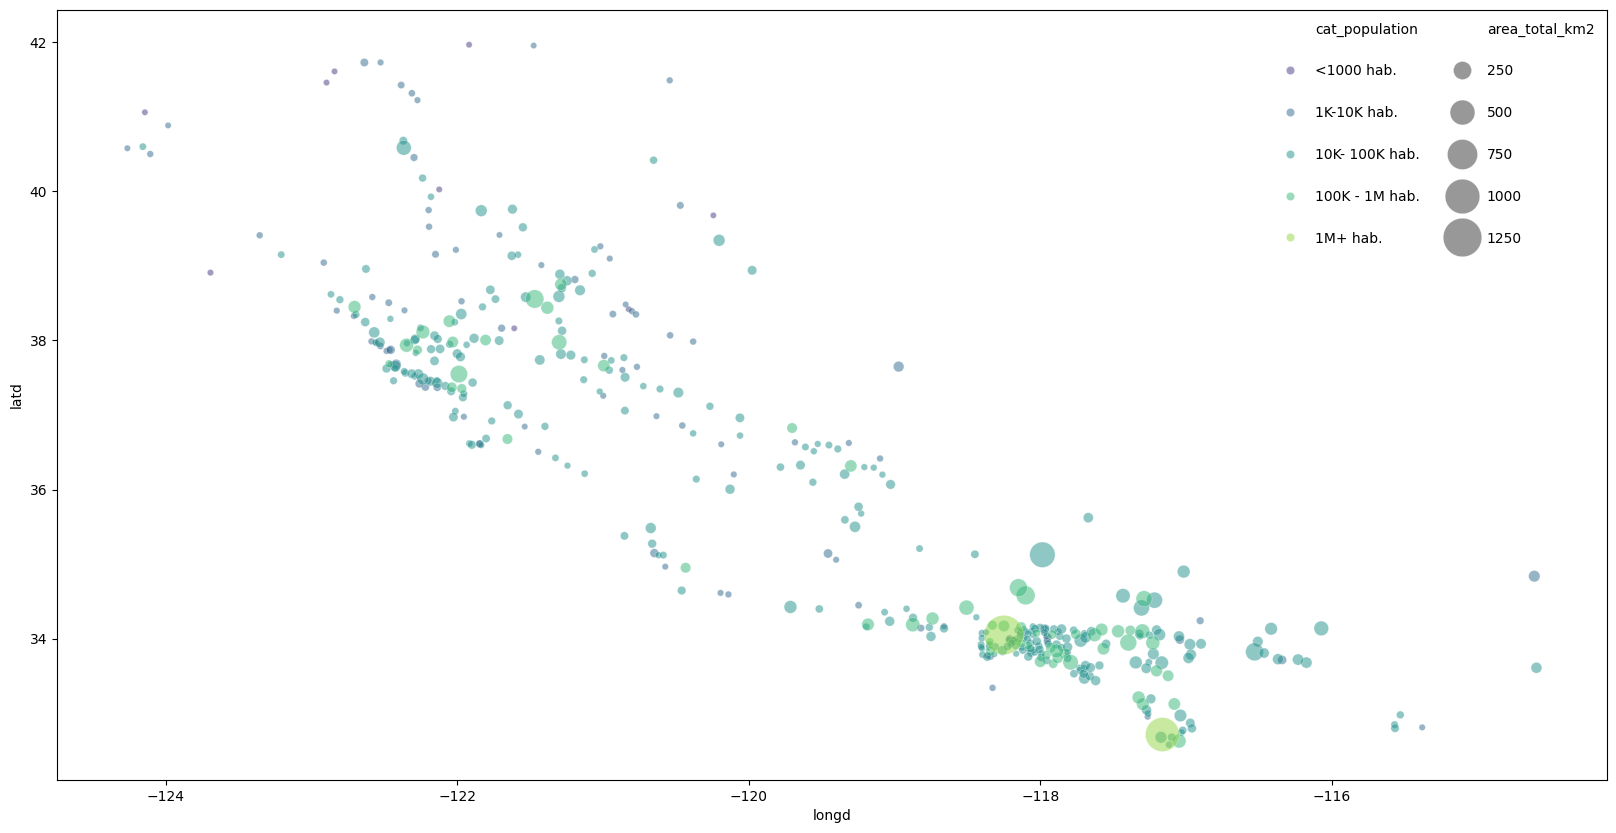

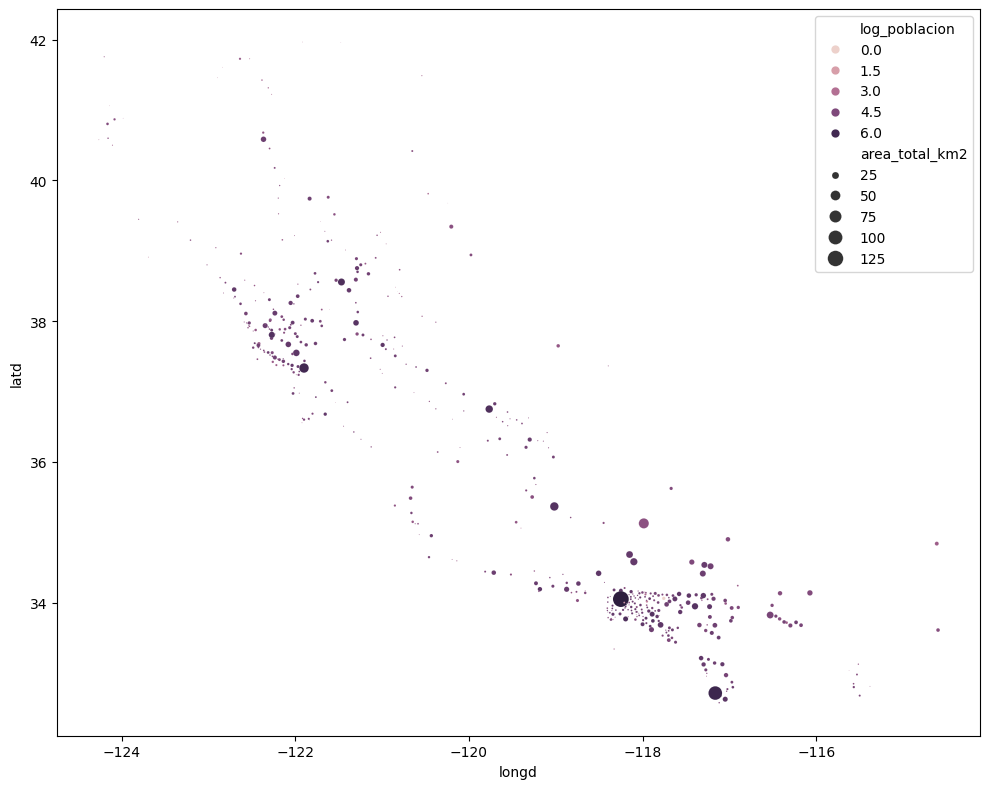

In [6]:
# TRANSFORMACIÓN LOGARÍTMICA
# diferencias de color visibles en todo el rango de población.
df['log_poblacion'] = np.log10(df['population_total'])

# LLAMADA BÁSICA A LA FUNCIÓN 
scatter_plot(
    df       = df,
    # Longitud en X, latitud en Y, para que los ejes del gráfico se convierten en un mapa.
    x_col    = 'longd',
    y_col    = 'latd',
    # población como color continuo.
    cat_col  = 'log_poblacion',
    # función usa df['area_total_km2'] * escala como tamaño.
    size     = 'area_total_km2',
    escala   = 1 / 10
)


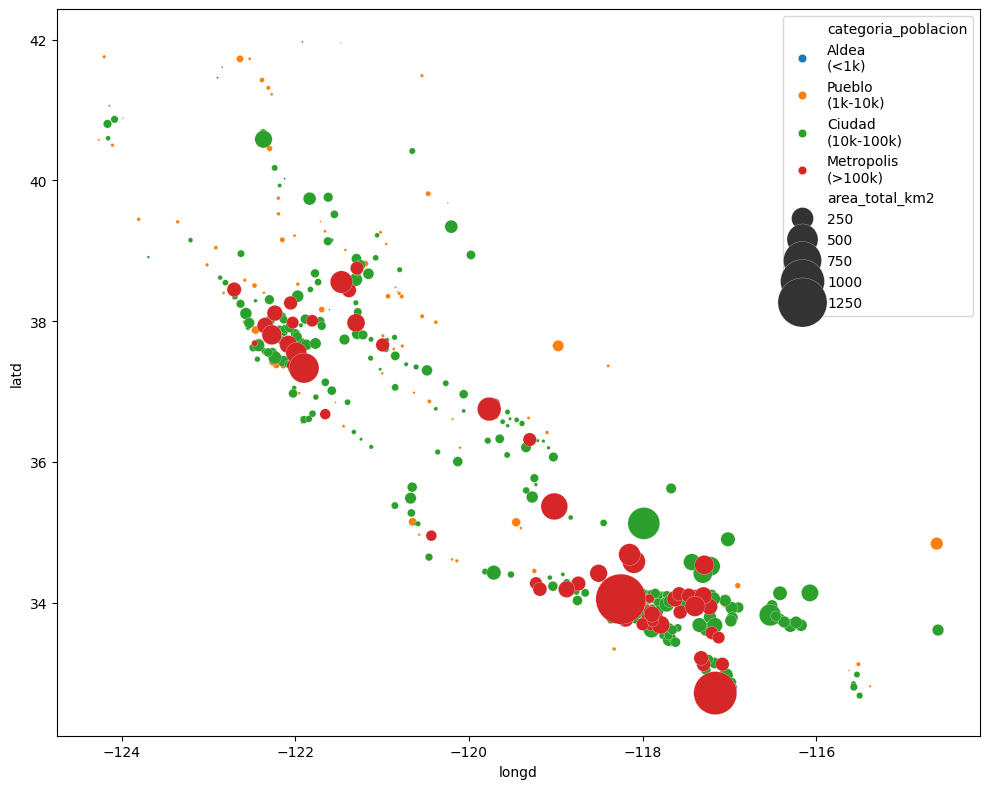

In [9]:
# ── OPCIONAL: CATEGORIZAR LA POBLACIÓN ───────────────────────────────────────

df['categoria_poblacion'] = pd.cut(df['log_poblacion'],
       bins   = [0, 3, 4, 5, 10],                               # cortes en log10
       labels = ['Aldea\n(<1k)', 'Pueblo\n(1k-10k)',
                 'Ciudad\n(10k-100k)', 'Metropolis\n(>100k)'])

scatter_plot(df.sort_values(['log_poblacion']), 'longd', 'latd',
             cat_col = 'categoria_poblacion',   
             size    = 'area_total_km2',
             escala  = 1)

## #2: Presentación

En esta parte tendrás que hacer dos cosas, crear una presentación sobre el titanic de no más de 6 slides, sin incluir portada, con los siguientes mensajes y su apoyo en datos:  
1- El titanic fue un accidente con una tasa de mortalidad alta.  
2- En esa ocasión los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  
3- ... que la clase en la que se viajes tuvo una influencia significativa y podría explicar...  
4- ... las diferencias de tasas de supervivencia entre mujeres y niños.    
5- Además aunque el puerto de embarque parece influir, se podría asumir que lo fue el tipo de pasaje que embarcó en cada uno.  

Y generar el notebook con las gráficas que vas a emplear en la presentación. Tienes que entregar ambas cosas.

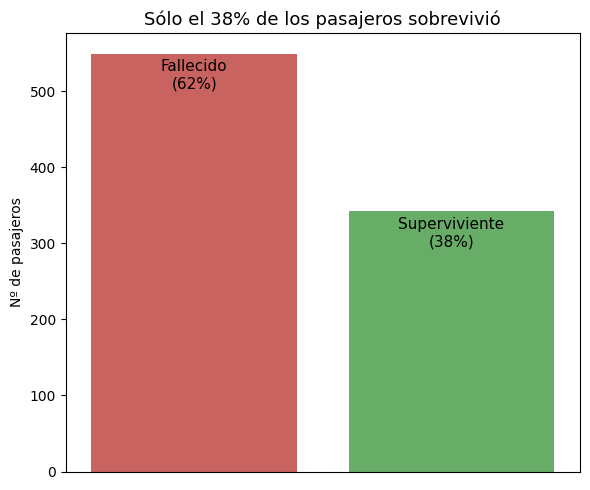

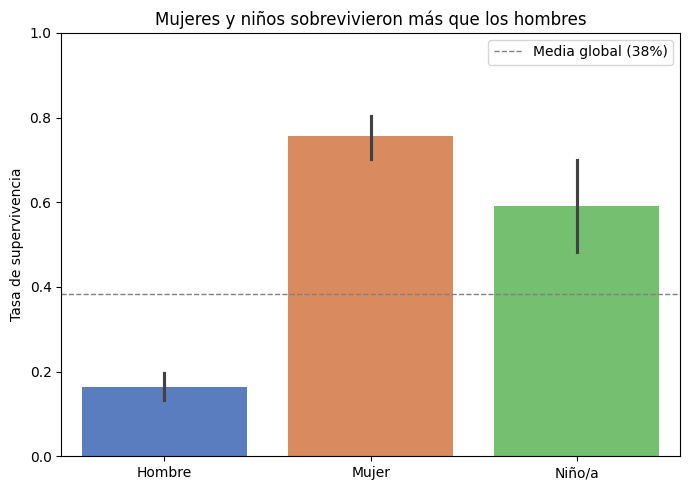

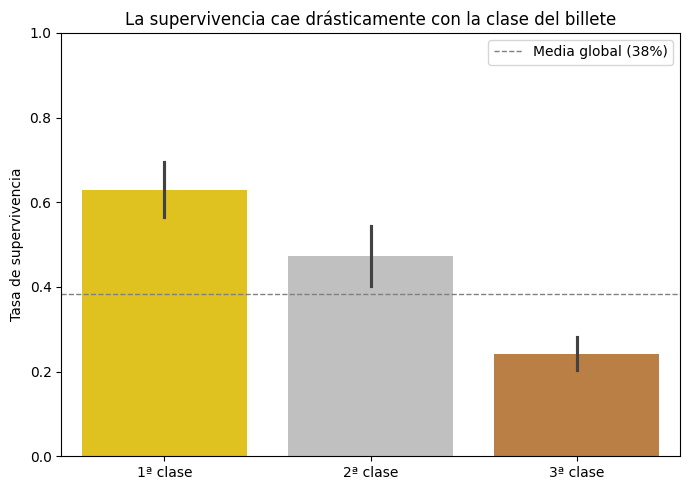

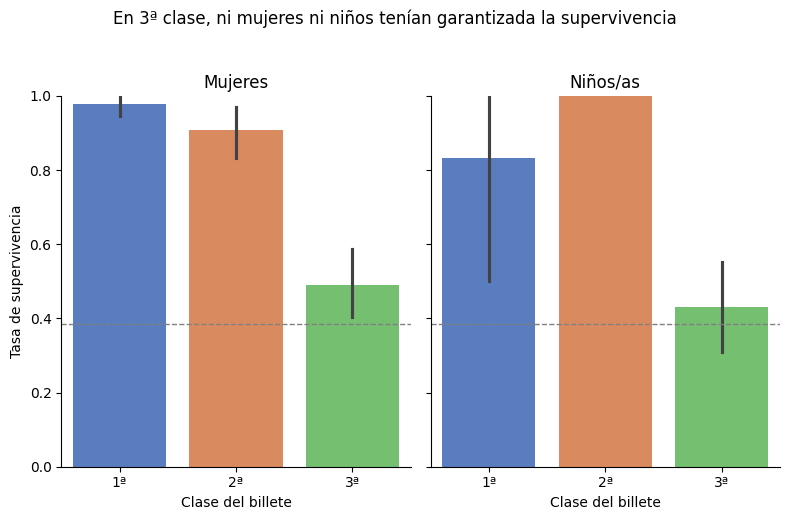

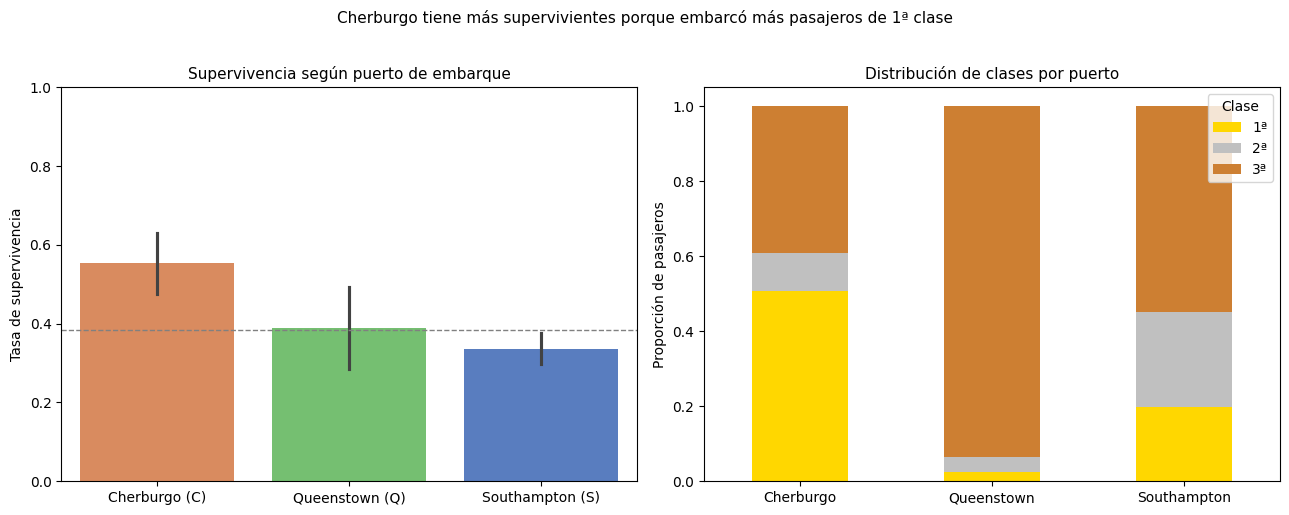

In [22]:
titanic = sns.load_dataset('titanic')
tasa_global = titanic['survived'].mean()


# ── DIAPOSITIVA 1 ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

sns.countplot(data=titanic, x='survived', hue='survived',   # FIX: hue=x
              order=[0, 1],
              palette=['#d9534f', '#5cb85c'],
              legend=False,                                  # FIX: ocultar leyenda redundante
              ax=ax)

for bar, label in zip(ax.patches, ['Fallecido\n(62%)', 'Superviviente\n(38%)']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() - 50,
            label, ha='center', va='bottom', fontsize=11)

ax.set_title('Sólo el 38% de los pasajeros sobrevivió', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Nº de pasajeros')
ax.set_xticks([])
plt.tight_layout()
plt.show()


# ── DIAPOSITIVA 2 ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

sns.barplot(data=titanic, x='who', y='survived', hue='who',  # FIX: hue=x
            order=['man', 'woman', 'child'],
            palette='muted', legend=False, ax=ax)             # FIX: legend=False

ax.set_xticks(range(3))                                       # FIX: anclar posiciones
ax.set_xticklabels(['Hombre', 'Mujer', 'Niño/a'])
ax.set_title('Mujeres y niños sobrevivieron más que los hombres', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Tasa de supervivencia')
ax.set_ylim(0, 1)
ax.axhline(tasa_global, linestyle='--', color='gray', linewidth=1,
           label=f'Media global ({tasa_global:.0%})')
ax.legend()
plt.tight_layout()
plt.show()


# ── DIAPOSITIVA 3 ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

sns.barplot(data=titanic, x='pclass', y='survived', hue='pclass',  # FIX
            palette=['gold', 'silver', '#cd7f32'],
            legend=False, ax=ax)                                     # FIX

ax.set_xticks(range(3))                                              # FIX
ax.set_xticklabels(['1ª clase', '2ª clase', '3ª clase'])
ax.set_title('La supervivencia cae drásticamente con la clase del billete', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Tasa de supervivencia')
ax.set_ylim(0, 1)
ax.axhline(tasa_global, linestyle='--', color='gray', linewidth=1,
           label=f'Media global ({tasa_global:.0%})')
ax.legend()
plt.tight_layout()
plt.show()


# ── DIAPOSITIVA 4 ─────────────────────────────────────────────────────────────
g = sns.catplot(
    data    = titanic[titanic['who'] != 'man'],
    kind    = 'bar',
    x       = 'pclass',
    y       = 'survived',
    hue     = 'pclass',    # FIX
    col     = 'who',
    palette = 'muted',
    legend  = False,       # FIX
    height  = 5, aspect = 0.8
)

for ax, titulo in zip(g.axes.flat, ['Mujeres', 'Niños/as']):
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Clase del billete')
    ax.set_ylabel('Tasa de supervivencia')
    ax.set_xticks(range(3))              # FIX
    ax.set_xticklabels(['1ª', '2ª', '3ª'])
    ax.set_ylim(0, 1)
    ax.axhline(tasa_global, linestyle='--', color='gray', linewidth=1)

g.figure.suptitle('En 3ª clase, ni mujeres ni niños tenían garantizada la supervivencia',
                  y=1.03, fontsize=12)
plt.tight_layout()
plt.show()


# ── DIAPOSITIVA 5 ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=titanic, x='embarked', y='survived', hue='embarked',  # FIX
            order=['C', 'Q', 'S'],
            palette='muted', legend=False, ax=axes[0])                  # FIX

axes[0].set_xticks(range(3))                                            # FIX
axes[0].set_xticklabels(['Cherburgo (C)', 'Queenstown (Q)', 'Southampton (S)'])
axes[0].set_title('Supervivencia según puerto de embarque', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Tasa de supervivencia')
axes[0].set_ylim(0, 1)
axes[0].axhline(tasa_global, linestyle='--', color='gray', linewidth=1)

clase_por_puerto = pd.crosstab(titanic['embarked'], titanic['pclass'],
                                normalize='index')
clase_por_puerto.plot(kind='bar', stacked=True,
                      color=['gold', 'silver', '#cd7f32'],
                      ax=axes[1])

axes[1].set_title('Distribución de clases por puerto', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('Proporción de pasajeros')
axes[1].set_xticks(range(3))                                            # FIX
axes[1].set_xticklabels(['Cherburgo', 'Queenstown', 'Southampton'], rotation=0)
axes[1].legend(title='Clase', labels=['1ª', '2ª', '3ª'])

plt.suptitle('Cherburgo tiene más supervivientes porque embarcó más pasajeros de 1ª clase',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


In [23]:
import nbformat

# ── CELDA 0: imports y datos ──────────────────────────────────────────────────
c0 = nbformat.v4.new_code_cell("""\
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

titanic = sns.load_dataset('titanic')
tasa_global = titanic['survived'].mean()
""")

# ── DIAPOSITIVA 1 ─────────────────────────────────────────────────────────────
m1 = nbformat.v4.new_markdown_cell("## Diapositiva 1 — El Titanic tuvo una tasa de mortalidad alta")

c1 = nbformat.v4.new_code_cell("""\
fig, ax = plt.subplots(figsize=(6, 5))
sns.countplot(data=titanic, x='survived', hue='survived',
              order=[0, 1], palette=['#d9534f', '#5cb85c'],
              legend=False, ax=ax)
for bar, label in zip(ax.patches, ['Fallecido\\n(62%)', 'Superviviente\\n(38%)']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            label, ha='center', va='bottom', fontsize=11)
ax.set_title('Sólo el 38% de los pasajeros sobrevivió', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Nº de pasajeros')
ax.set_xticks([])
plt.tight_layout()
plt.show()
""")

# ── DIAPOSITIVA 2 ─────────────────────────────────────────────────────────────
m2 = nbformat.v4.new_markdown_cell("## Diapositiva 2 — Los datos apoyan 'mujeres y niños primero'")

c2 = nbformat.v4.new_code_cell("""\
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=titanic, x='who', y='survived', hue='who',
            order=['man', 'woman', 'child'],
            palette='muted', legend=False, ax=ax)
ax.set_xticks(range(3))
ax.set_xticklabels(['Hombre', 'Mujer', 'Niño/a'])
ax.set_title('Mujeres y niños sobrevivieron más que los hombres', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Tasa de supervivencia')
ax.set_ylim(0, 1)
ax.axhline(tasa_global, linestyle='--', color='gray', linewidth=1,
           label=f'Media global ({tasa_global:.0%})')
ax.legend()
plt.tight_layout()
plt.show()
""")

# ── DIAPOSITIVA 3 ─────────────────────────────────────────────────────────────
m3 = nbformat.v4.new_markdown_cell("## Diapositiva 3 — La clase tuvo una influencia significativa")

c3 = nbformat.v4.new_code_cell("""\
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=titanic, x='pclass', y='survived', hue='pclass',
            palette=['gold', 'silver', '#cd7f32'],
            legend=False, ax=ax)
ax.set_xticks(range(3))
ax.set_xticklabels(['1ª clase', '2ª clase', '3ª clase'])
ax.set_title('La supervivencia cae drásticamente con la clase del billete', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Tasa de supervivencia')
ax.set_ylim(0, 1)
ax.axhline(tasa_global, linestyle='--', color='gray', linewidth=1,
           label=f'Media global ({tasa_global:.0%})')
ax.legend()
plt.tight_layout()
plt.show()
""")

# ── DIAPOSITIVA 4 ─────────────────────────────────────────────────────────────
m4 = nbformat.v4.new_markdown_cell("## Diapositiva 4 — La clase explica las diferencias entre mujeres y niños")

c4 = nbformat.v4.new_code_cell("""\
g = sns.catplot(
    data    = titanic[titanic['who'] != 'man'],
    kind    = 'bar',
    x       = 'pclass',
    y       = 'survived',
    hue     = 'pclass',
    col     = 'who',
    palette = 'muted',
    legend  = False,
    height  = 5, aspect = 0.8
)
for ax, titulo in zip(g.axes.flat, ['Mujeres', 'Niños/as']):
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Clase del billete')
    ax.set_ylabel('Tasa de supervivencia')
    ax.set_xticks(range(3))
    ax.set_xticklabels(['1ª', '2ª', '3ª'])
    ax.set_ylim(0, 1)
    ax.axhline(tasa_global, linestyle='--', color='gray', linewidth=1)
g.figure.suptitle('En 3ª clase, ni mujeres ni niños tenían garantizada la supervivencia',
                  y=1.03, fontsize=12)
plt.tight_layout()
plt.show()
""")

# ── DIAPOSITIVA 5 ─────────────────────────────────────────────────────────────
m5 = nbformat.v4.new_markdown_cell("## Diapositiva 5 — El puerto parece influir, pero lo explica la clase")

c5 = nbformat.v4.new_code_cell("""\
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=titanic, x='embarked', y='survived', hue='embarked',
            order=['C', 'Q', 'S'], palette='muted', legend=False, ax=axes[0])
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(['Cherburgo (C)', 'Queenstown (Q)', 'Southampton (S)'])
axes[0].set_title('Supervivencia según puerto de embarque', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Tasa de supervivencia')
axes[0].set_ylim(0, 1)
axes[0].axhline(tasa_global, linestyle='--', color='gray', linewidth=1)

clase_por_puerto = pd.crosstab(titanic['embarked'], titanic['pclass'], normalize='index')
clase_por_puerto.plot(kind='bar', stacked=True,
                      color=['gold', 'silver', '#cd7f32'], ax=axes[1])
axes[1].set_title('Distribución de clases por puerto', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('Proporción de pasajeros')
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(['Cherburgo', 'Queenstown', 'Southampton'], rotation=0)
axes[1].legend(title='Clase', labels=['1ª', '2ª', '3ª'])

plt.suptitle('Cherburgo tiene más supervivientes porque embarcó más pasajeros de 1ª clase',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()
""")

# ── ENSAMBLAR Y ESCRIBIR EL NOTEBOOK ─────────────────────────────────────────
nb = nbformat.v4.new_notebook(cells=[c0, m1, c1, m2, c2, m3, c3, m4, c4, m5, c5])

ruta = './presentacion_titanic.ipynb'
with open(ruta, 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)

print(f"Notebook generado en: {ruta}")



Notebook generado en: ./presentacion_titanic.ipynb
